In [1]:
# 用PyTorch内置数据集和DataLoader加载数据
%matplotlib inline
import torch
from torch.utils.data import Dataset
from torchvision import datasets
from torchvision.transforms import ToTensor, Lambda
import matplotlib.pyplot as plt

In [2]:
torch.__version__

'1.11.0+cu113'

In [3]:
# 加载 FashionMNIST数据集
training_data = datasets.FashionMNIST(
    root=r'E:\ml\dataset\cv',
    train=True,
    download=True,
    transform=ToTensor()
)

test_data = datasets.FashionMNIST(
    root=r'E:\ml\dataset\cv',
    train=False,
    download=True,
    transform=ToTensor()
)

26422272it [00:05, 5238157.64it/s]                              


Extracting E:\ml\dataset\cv\FashionMNIST\raw\train-images-idx3-ubyte.gz to E:\ml\dataset\cv\FashionMNIST\raw



29696it [00:00, 159360.65it/s]                           


Extracting E:\ml\dataset\cv\FashionMNIST\raw\train-labels-idx1-ubyte.gz to E:\ml\dataset\cv\FashionMNIST\raw



4422656it [00:01, 2696400.26it/s]                             


Extracting E:\ml\dataset\cv\FashionMNIST\raw\t10k-images-idx3-ubyte.gz to E:\ml\dataset\cv\FashionMNIST\raw



6144it [00:00, 770789.45it/s]           

Extracting E:\ml\dataset\cv\FashionMNIST\raw\t10k-labels-idx1-ubyte.gz to E:\ml\dataset\cv\FashionMNIST\raw



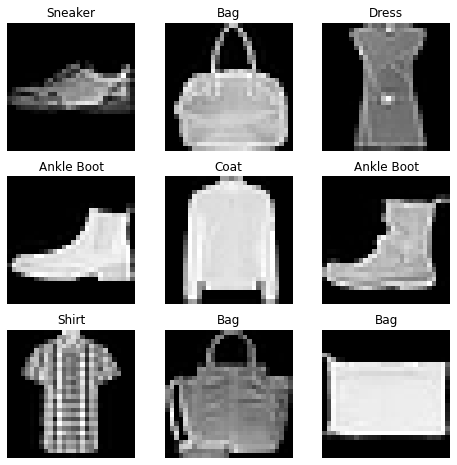

In [10]:
# 使用matplotlib可视化一些样本
labels_map = {
    0: "T-Shirt",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle Boot",
}
figure = plt.figure(figsize=(8, 8))
cols, rows, = 3, 3
for i in range(1, cols*rows+1):
    sample_idx = torch.randint(len(training_data), size=(1,)).item()
    img, label = training_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(labels_map[label])
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

In [11]:
# 创建自己的数据集
# 必须实现__init__, __len__, __getitem__方法
import os
import pandas as pd
import torchvision.io as tvio

In [12]:
class CustomImageDataset(Dataset):
    def __init__(self, annotation_file, img_dir, transform=None, target_transform=None):
        self.img_labels = pd.read_csv(annotation_file)
        self.img_dir = img_dir
        self.transform = transform
        self.target_transform = target_transform

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.img_labels.iloc[idx, 0])
        image = tvio.read_image(img_path)
        label = self.img_labels.iloc[idx, 1]
        if self.transform:
            image = self.transform(image)
        if self.target_transform:
            label = self.target_transform(label)
        sample = {'image': image, 'label': label}
        return sample

In [13]:
# 使用DataLoader准备训练数据
from torch.utils.data import DataLoader

train_dataloader = DataLoader(training_data, batch_size=64, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=64, shuffle=True)

Features batch shape: torch.Size([64, 1, 28, 28])
Labels batch shape: torch.Size([64])


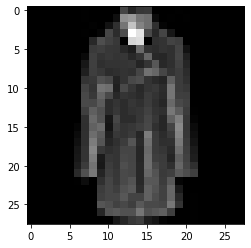

Label: 4


In [14]:
train_features, train_labels = next(iter(train_dataloader))
print(f"Features batch shape: {train_features.size()}")
print(f"Labels batch shape: {train_labels.size()}")
img = train_features[0].squeeze()
label = train_labels[0]
plt.imshow(img, cmap='gray')
plt.show()
print(f"Label: {label}")

In [15]:
# 使用transform转换数据
from torchvision import datasets
from torchvision.transforms import ToTensor, Lambda

In [16]:
# Lambda可以使用我们自定义的转换方式
ds = datasets.FashionMNIST(
    root=r'E:\ml\dataset\cv',
    train=True,
    download=True,
    transform=ToTensor(),
    target_transform=Lambda(lambda y: torch.zeros(10, dtype=torch.float).scatter_(0, torch.tensor(y), value=1))
)